In [2]:

import matplotlib.pyplot as plt
import numpy as np
import graph_style as gs
import fig_helper as fh
from scipy.optimize import curve_fit


def linear_fit(t, a, b):
    return a * t + b


gs.set_graph_style(1.0)


In [3]:

date = "2025-06-05"
rid = 36400

dict = fh.load_data(rid, date)


In [19]:

num_pulses = np.array(dict["datasets"][f"ndscan.rid_{rid}.points.axis_0"])
pop = np.array(
    dict["datasets"][f"ndscan.rid_{rid}.points.channel_measurement_camera_readout_p"]
)
pop_err = np.array(
    dict["datasets"][
        f"ndscan.rid_{rid}.points.channel_measurement_camera_readout_p_err"
    ]
)
argsort = np.argsort(num_pulses)
num_pulses = num_pulses[argsort]
pop = 1 - pop  # convert to excitation probability
pop = pop[argsort]
pop_err = pop_err[argsort]

# n_lin = 7
# p_fit, p_cov = curve_fit(
#     linear_fit,
#     num_pulses[:n_lin],
#     pop_log[:n_lin],
#     sigma=pop_err_log[:n_lin],
# )

# p_err = np.sqrt(np.diag(p_cov))

min_pop = np.min(pop)
min_pop_err = pop_err[np.argmin(pop)]
print(f"min pop: {1-min_pop:.3e} +/- {min_pop_err:.3e}")


min pop: 9.996e-01 +/- 2.538e-04


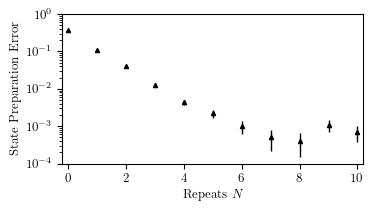

In [21]:
fig_width = gs.get_fig_width()*2/3
fig_height = fig_width * 1/2
fig = plt.figure(figsize=(fig_width, fig_height))

c = "k"
plt.errorbar(
    num_pulses, pop, yerr=pop_err, fmt="^", color=c, zorder=11, elinewidth=1.0
)
plt.xlabel("Repeats $N$")
plt.ylabel("State Preparation Error")
# relabel y-axis ticks
plt.xlim([-0.2, np.max(num_pulses)+0.2])
plt.ylim([10**(-4), 1])
plt.yscale("log")
plt.grid(None)

f_name = "..\\..\\pdf_figure\\ch4\\state_prep.pdf"
plt.savefig(f_name, bbox_inches="tight")